# Прогноз оттока клиентов фитнес-центра


## Задачи проекта

* спрогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
* сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
* проанализировать основные признаки, наиболее сильно влияющие на отток;
* сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
    * выделить целевые группы клиентов;
    * предложить меры по снижению оттока;
    * определить другие особенности взаимодействия с клиентами.

## Описание данных
Данные клиента за предыдущий до проверки факта оттока месяц:
 - `gender` — пол;
 - `Near_Location` — проживание или работа в районе, где находится фитнес-центр;
 - `Partner` — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
 - `Promo_friends` — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
 - `Phone` — наличие контактного телефона;
 - `Age` — возраст;
 - `Lifetime` — время с момента первого обращения в фитнес-центр (в месяцах).
 

Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:
 - `Contract_period` — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
 - `Month_to_end_contract` — срок до окончания текущего действующего абонемента (в месяцах);
 - `Group_visits` — факт посещения групповых занятий;
 - `Avg_class_frequency_total` — средняя частота посещений в неделю за все время с начала действия абонемента;
 - `Avg_class_frequency_current_month` — средняя частота посещений в неделю за предыдущий месяц;
 - `Avg_additional_charges_total` — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
 - `Churn` — факт оттока в текущем месяце.

## 1. Загрузка данных.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Информация о датасете
df = pd.read_csv('gym_churn.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [3]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
# Проверка наличия явных дубликатов
df.duplicated().sum()

np.int64(0)

In [5]:
# Приводим название столбцов в нижний регистр
df.columns = df.columns.str.lower()
df.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


**Вывод**: в датасете содержится информация о 4000 пользователей. Пропусков и явных дубликаков не обнаружено. Большинство пользователей (84,5%) живут или работают рядом с фитнес-клубом. Средняя продолжительность заключения контракта составляет 4,68 месяцев (50-перцентиль составляет 1 месяц). Средний возраст посетителей фитнес-клуба - 29 лет (минимальный - 18 лет, максимальный - 41 год). В среднем люди посещают зал 3,7 месяца (50% посещают меньше 3 месяцев). Среднее количество посещений в неделю за всё время практически не отличается от того же показателя за предыдущий месяц и составляет 1,87 и 1,76 соответственно. Доля оттока - 26,5%.  

## 2. Исследовательский анализ данных.

In [7]:
# Разделим клиентов на 2 группы по churn
df.groupby('churn').mean().T

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


**Вывод**: распределение по полу произошло равномерно. Среди ушедших клиентов доля тех, кто не живёт или не работает рядом с залом, больше на 11% по сравнению с теми, кто продолжает заниматься. Среди остающихся клиентов доля "партнёров" на 18% больше. Доля клиентов с акцией "приведи друга" среди ушедших на 17% меньше. Длительность оформленного договора у ушедших клиентов на 4 месяца меньше. Групповые занятия они посещают почти в 2 раза меньше. Средний возраст у ушедших клиентов меньше (около 27 лет). В среднем они тратили на 43 рубля меньше на дополнительные услуги фитнес-центра. Среднее количество месяцев до окончания контракта составляет 1,66 месяц у ушедших клиентов против 5,28 у оставшихся. Среднее количество месяцев с первого обращения у оставшихся клиентов почти в 5 раз больше, чем у ушедших (4,71 против 0,99 месяцев). Среднее количество посещений в неделю за всё время и за последний месяц почти не различается внутри групп и составляет 2,02 у оставшихся клиентов и 1,4 у ушедших клиентов.

In [ ]:
# Выделяем 2 группы ушедших и оставшихся клиентов
churn_0 = df[df['churn'] == 0]
churn_1 = df[df['churn'] == 1]

C:\Users\Камила\AppData\Local\Temp\ipykernel_67748\2087716588.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


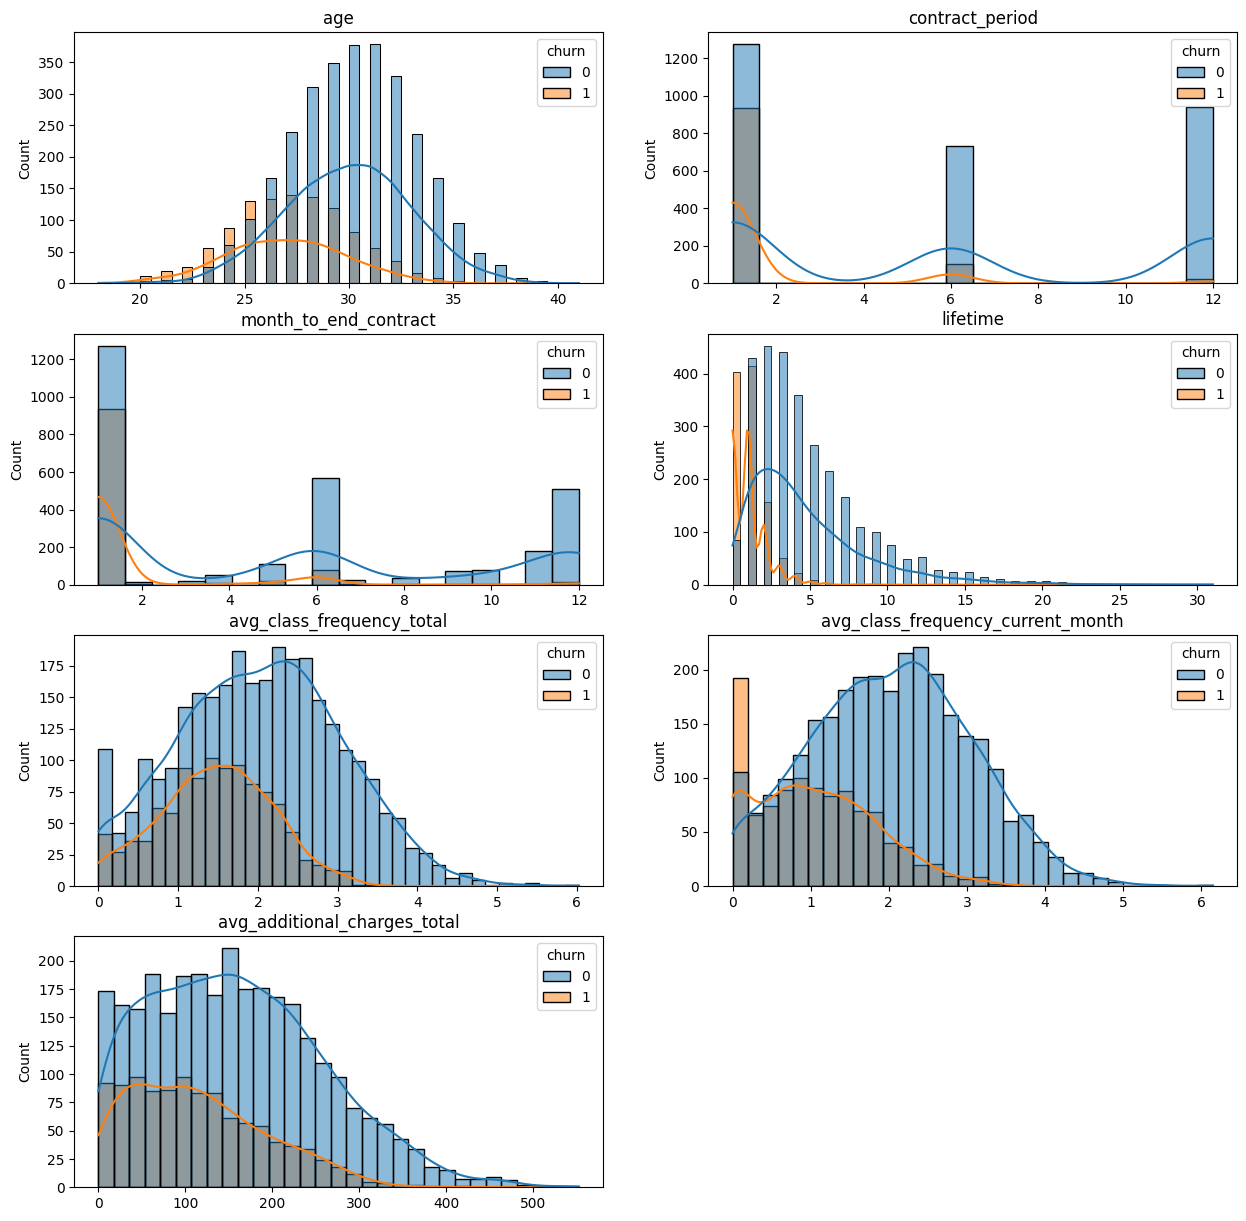

In [9]:
# Построим графики распределения для числовых признаков с разделением по ушедшим и оставшимся клиентам
num_features = ['age', 'contract_period', 'month_to_end_contract', 'lifetime', 'avg_class_frequency_total', 'avg_class_frequency_current_month', 
'avg_additional_charges_total']

n_row = int(len(num_features)/2)
fig, ax = plt.subplots(nrows=n_row + 1, ncols=2, figsize=(15, 15))
ax = ax.flatten()
for i in range(len(num_features)):
    sns.histplot(data = df, x = df[num_features[i]], hue='churn', ax=ax[i], kde = True)
    ax[i].set_title(f'{num_features[i]}')
    ax[i].set_xlabel('')
fig.delaxes(ax[-1])  
fig.show()

**Вывод**: отток наиболее выражен у клиентов в возрасте 25-28 лет. Чаще всего уходят пользователи с договором на 1 месяц и уходят после первого месяца. Они посещают фитнес-центр от 0 до 3 раз в неделю. На дополнительные услуги тратят в среднем меньше, чем оставшиеся пользователи. 

C:\Users\Камила\AppData\Local\Temp\ipykernel_67748\2923522171.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


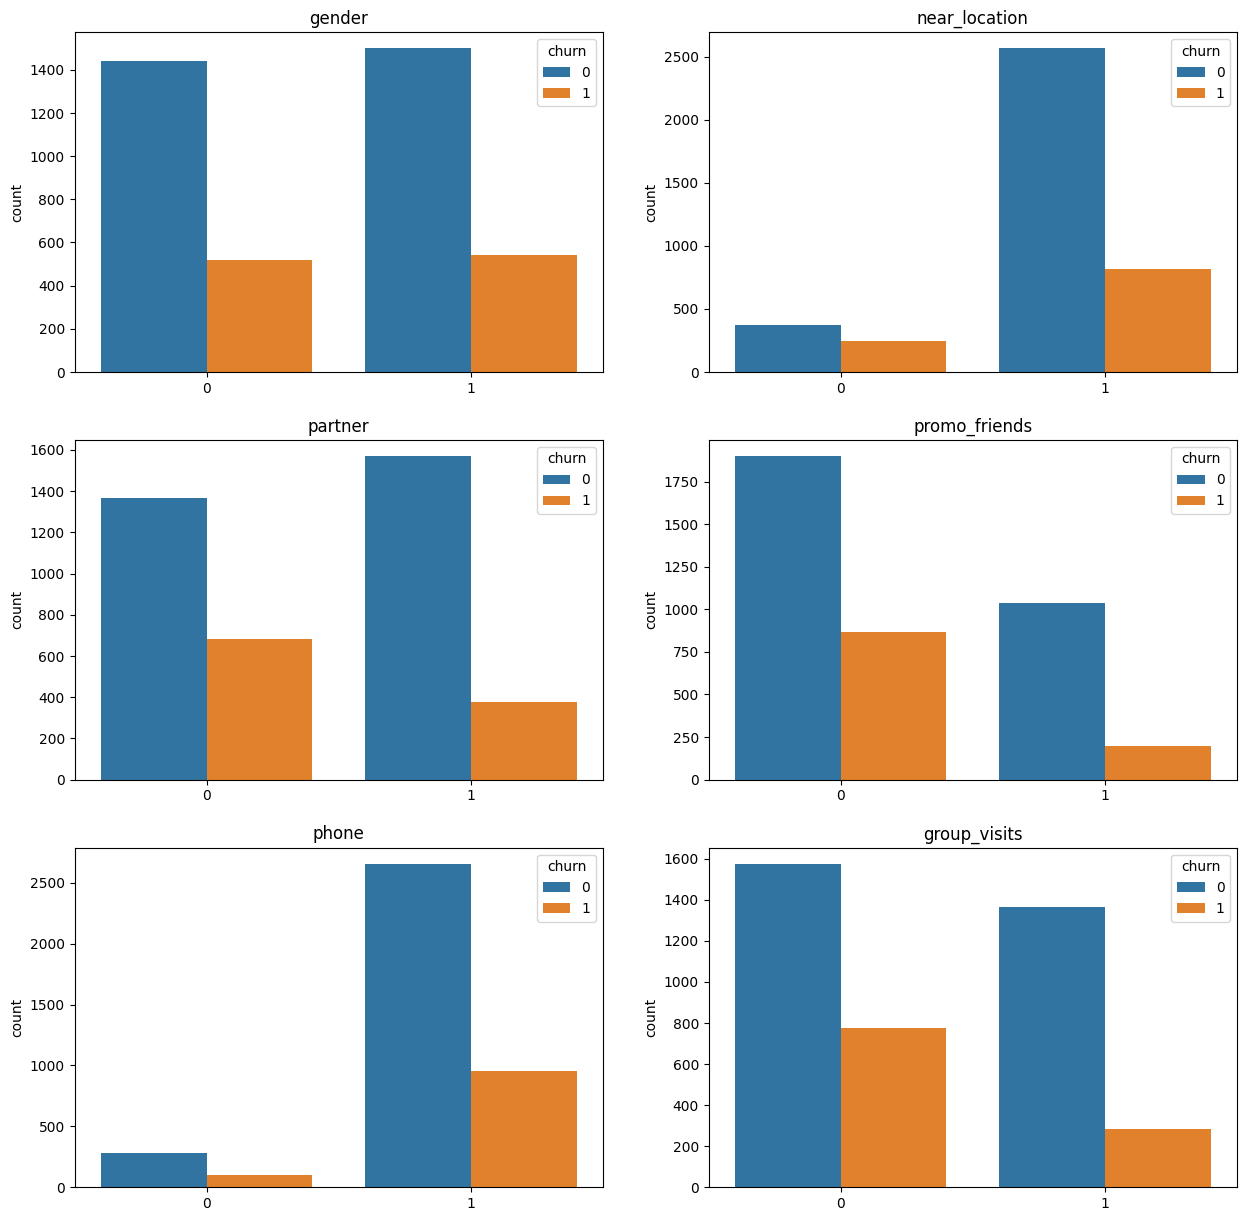

In [10]:
# Построим графики распределения для бинарных признаков с разделением по ушедшим и оставшимся клиентам
bin_features = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits']
n_rows = int(len(bin_features) / 2)
fig, ax = plt.subplots(nrows=n_rows, ncols=2, figsize=(15, 15))
ax = ax.flatten()
for i in range(len(bin_features)):
    sns.countplot(x=df[bin_features[i]], hue='churn', data=df, ax=ax[i])
    ax[i].set_title(f'{bin_features[i]}')
    ax[i].set_xlabel('')
fig.show()

**Вывод**: распределение по полу между группами одинаковое. Клиенты, которые отказываются от услуг фитнес-центра, чаще живут или работают далеко от самого центра. Клиенты уходят чаще, если не являются партнёрами или привлечёнными друзьями. Также третья часть из тех, кто не посещает групповые тренировки, уходят.

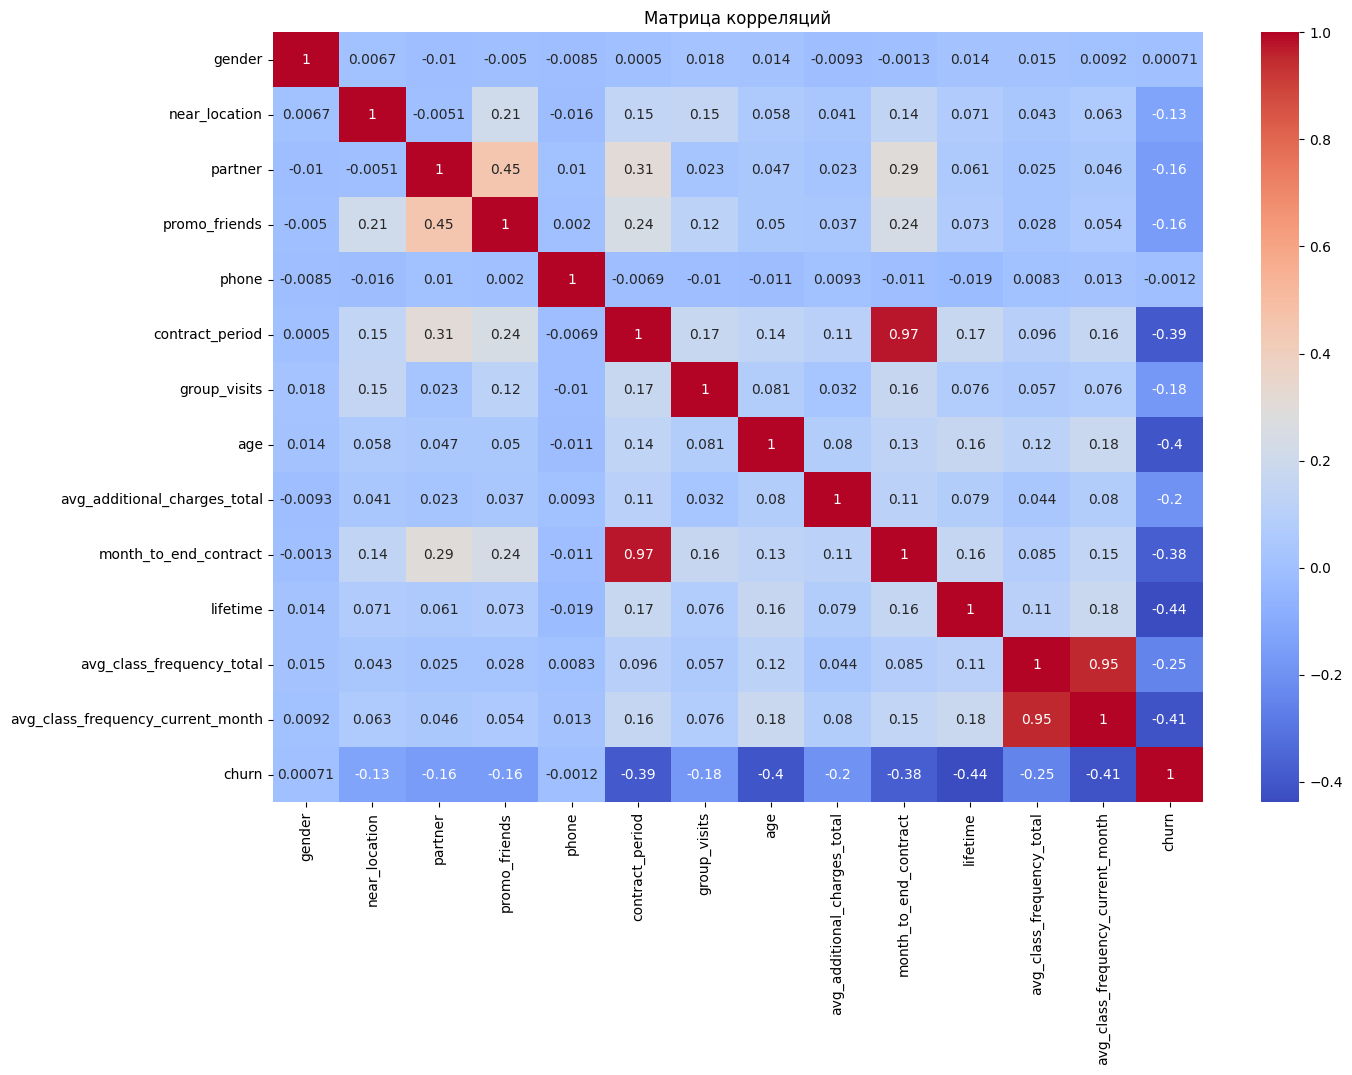

In [11]:
# Матрица корреляции признаков
corr_m = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_m, annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Заметим, что у признаков `month_to_end_contract` и `contract_period`, `avg_class_frequency_current_month` и `avg_class_frequency_total` присутствует мультиколлинеарность. Для дальнейшего построения моделей исключим по одному признаку из каждой пары сильно коррелирующих признаков.

In [ ]:
# Убираем мультиколлинеарные признаки, оставляем только один из пары признаков с высокой корреляцией
df_model = df.drop(['month_to_end_contract', 'avg_class_frequency_current_month'], axis=1)


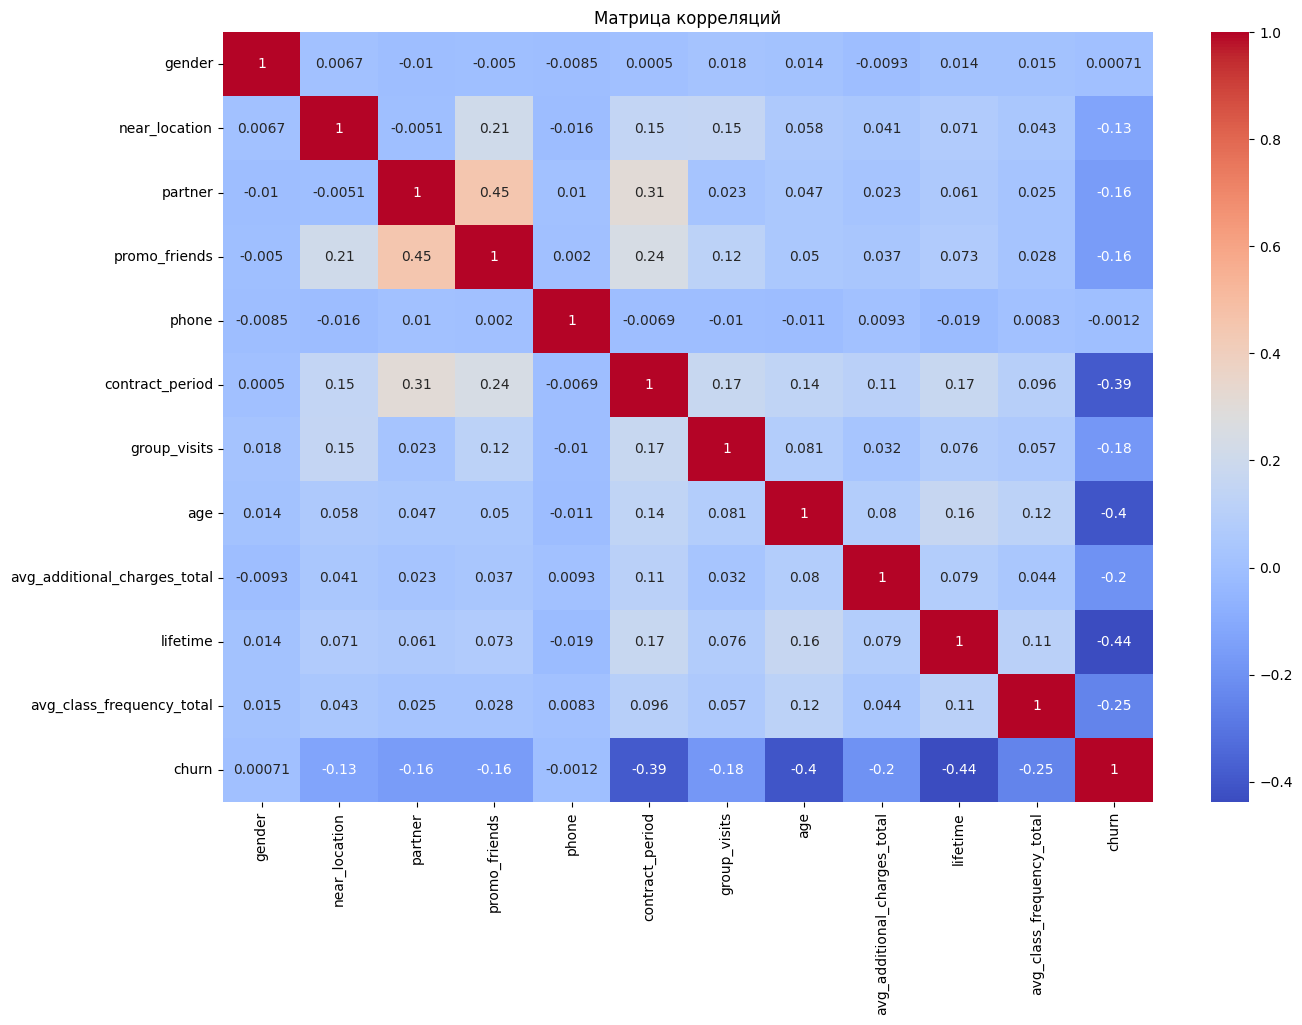

In [ ]:
# Новая корреляционная матрица после удаления мультиколлинеарных признаков
corr_m = df_model.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_m, annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

**Вывод:** наиболее сильно коррелируют признаки `month_to_end_contract` и `contract_period`, `avg_class_frequency_current_month` и `avg_class_frequency_total`. Также умеренная связь наблюдается между признаками `promo_friends` и `partner`. С `churn` умеренно коррелируют признаки `contract_period`, `age`, `lifetime`, `avg_class_frequency_total`, причём корреляция везде отрицательная. Минимальную корреляционную связь с оттоком показывают признаки `phone`, `near_location` и `gender`.

## 3. Модель прогнозирования оттока.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [ ]:
# Создание признаков и целевой переменной
X = df_model.drop('churn', axis=1)
y = df_model['churn']

In [ ]:
# Разделение данных на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Стандартизация признаков
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [ ]:
# Обучение и оценка качества логистической регрессии 
log_model = LogisticRegression(random_state=0)
log_model.fit(x_train_s, y_train)
pred_log = log_model.predict(x_test_s)

print('Логистическая регрессия')
print(f'Accuracy = {accuracy_score(y_test, pred_log)}')
print(f'Precision = {precision_score(y_test, pred_log)}')
print(f'Recall = {recall_score(y_test, pred_log)}')
print(f'F1-score = {f1_score(y_test, pred_log)}')

Логистическая регрессия
Accuracy = 0.89875
Precision = 0.7881773399014779
Recall = 0.8080808080808081
F1-score = 0.7980049875311721


In [ ]:
# Обучение и оценка качества случайного леса
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)
forest_model.fit(x_train_s, y_train)
pred_forest = forest_model.predict(x_test_s)

print('Рандомный лес')
print(f'Accuracy = {accuracy_score(y_test, pred_forest)}')
print(f'Precision = {precision_score(y_test, pred_forest)}')
print(f'Recall = {recall_score(y_test, pred_forest)}')
print(f'F1-score = {f1_score(y_test, pred_forest)}')

Рандомный лес
Accuracy = 0.89
Precision = 0.7864583333333334
Recall = 0.7626262626262627
F1-score = 0.7743589743589744


**Вывод:** модели показали одинаковый результат в метриках accuracy = 0.89 и precision = 0.79. Однако логистическая регрессия показала лучший recall = 0,8 и f1-score = 0,79. Соответственно, в качестве основной модели для предсказания оттока клиентов следует использовать её.

## 4. Кластеризация клиентов.

In [ ]:
# Для кластеризации убираем целевой признак churn
df_clust = df.drop('churn', axis=1)

In [21]:
# Стандартизация данных
scaler_clust = StandardScaler()
x_s = scaler_clust.fit_transform(df_clust)


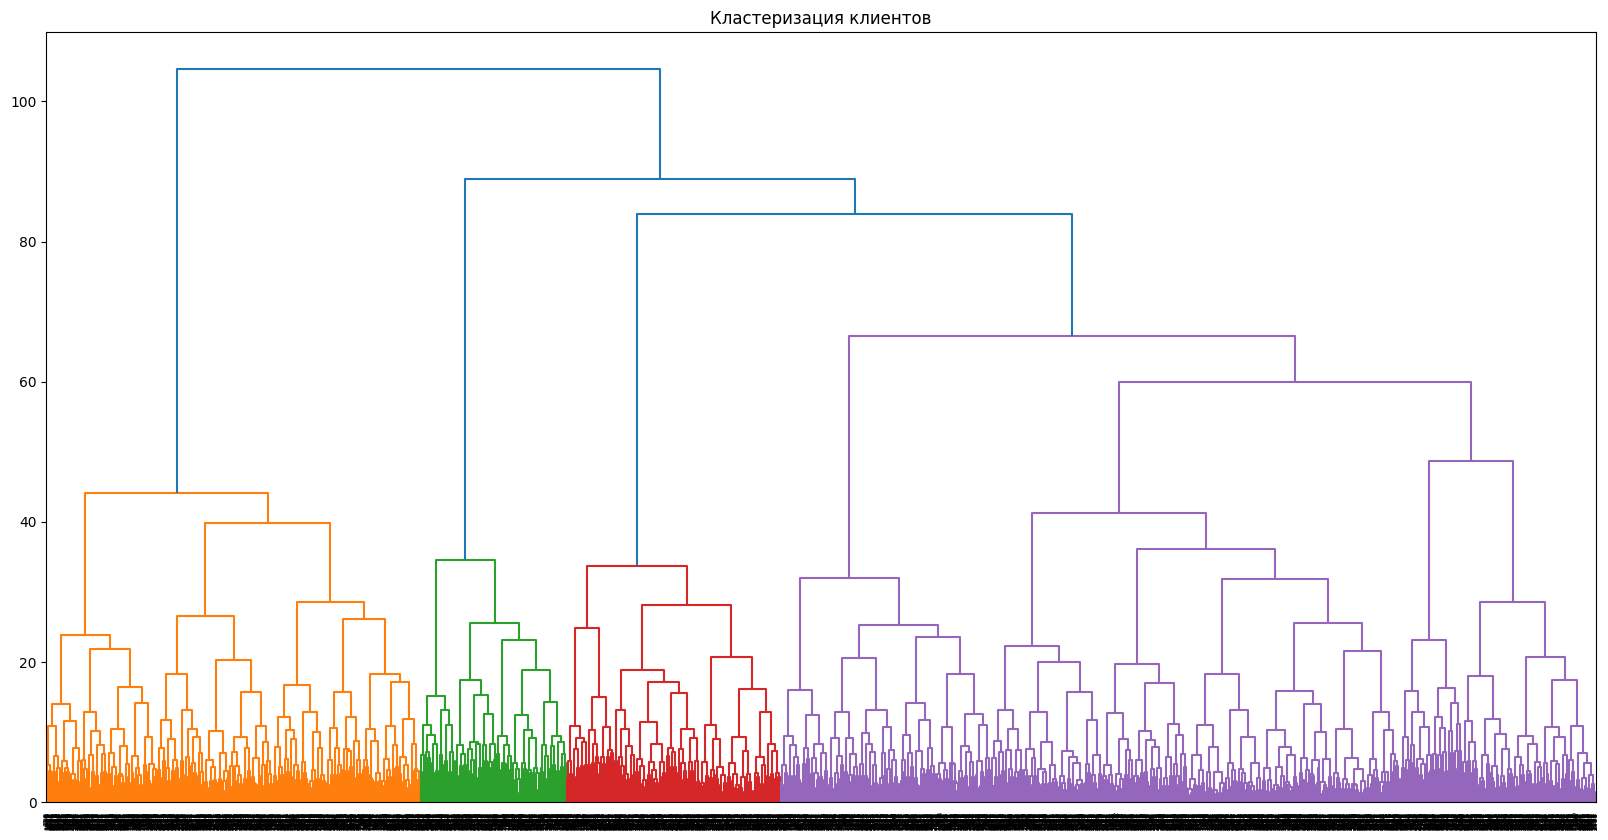

In [ ]:
# Иерархическая кластеризация
linked = linkage(x_s, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(linked)
plt.title('Кластеризация клиентов')
plt.show()

Вывод: на дендрограмме можем выделить 4-6 кластеров. Попробуем выделить 5 кластеров.

In [44]:
# В качестве модели кластеризации выберем KMeans
model_clust = KMeans(n_clusters = 5, random_state=0)
labels = model_clust.fit_predict(x_s)
df['cluster'] = labels

In [45]:
# Средние значения признаков по кластерам
df.groupby('cluster').mean().T

cluster,0,1,2,3,4
gender,0.486819,0.592493,0.499469,0.483360,0.496324
near_location,1.000000,0.970509,0.943677,1.000000,0.000000
partner,0.243409,0.288204,0.740701,0.798732,0.466912
promo_friends,0.007030,0.123324,0.489904,1.000000,0.077206
phone,0.899824,0.898123,0.900106,0.911252,0.915441
contract_period,1.978910,2.898123,11.866100,3.079239,2.209559
group_visits,0.326889,0.482574,0.551541,0.445325,0.215074
age,28.239016,30.339142,29.905420,29.052298,28.483456
avg_additional_charges_total,130.877033,164.193829,165.146492,139.858265,133.630215
month_to_end_contract,1.896309,2.654155,10.852285,2.873217,2.073529


In [ ]:
# Доля ушедших клиентов для каждого кластера
df.groupby('cluster')['churn'].mean().sort_values(ascending=False).T

cluster
0    0.513181
4    0.450368
3    0.269414
1    0.054960
2    0.022317
Name: churn, dtype: float64

In [ ]:
# Количество клиентов в каждом кластере
df.groupby('cluster').count()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,1138,1138,1138,1138,1138,1138,1138,1138,1138,1138,1138,1138,1138,1138
1,746,746,746,746,746,746,746,746,746,746,746,746,746,746
2,941,941,941,941,941,941,941,941,941,941,941,941,941,941
3,631,631,631,631,631,631,631,631,631,631,631,631,631,631
4,544,544,544,544,544,544,544,544,544,544,544,544,544,544


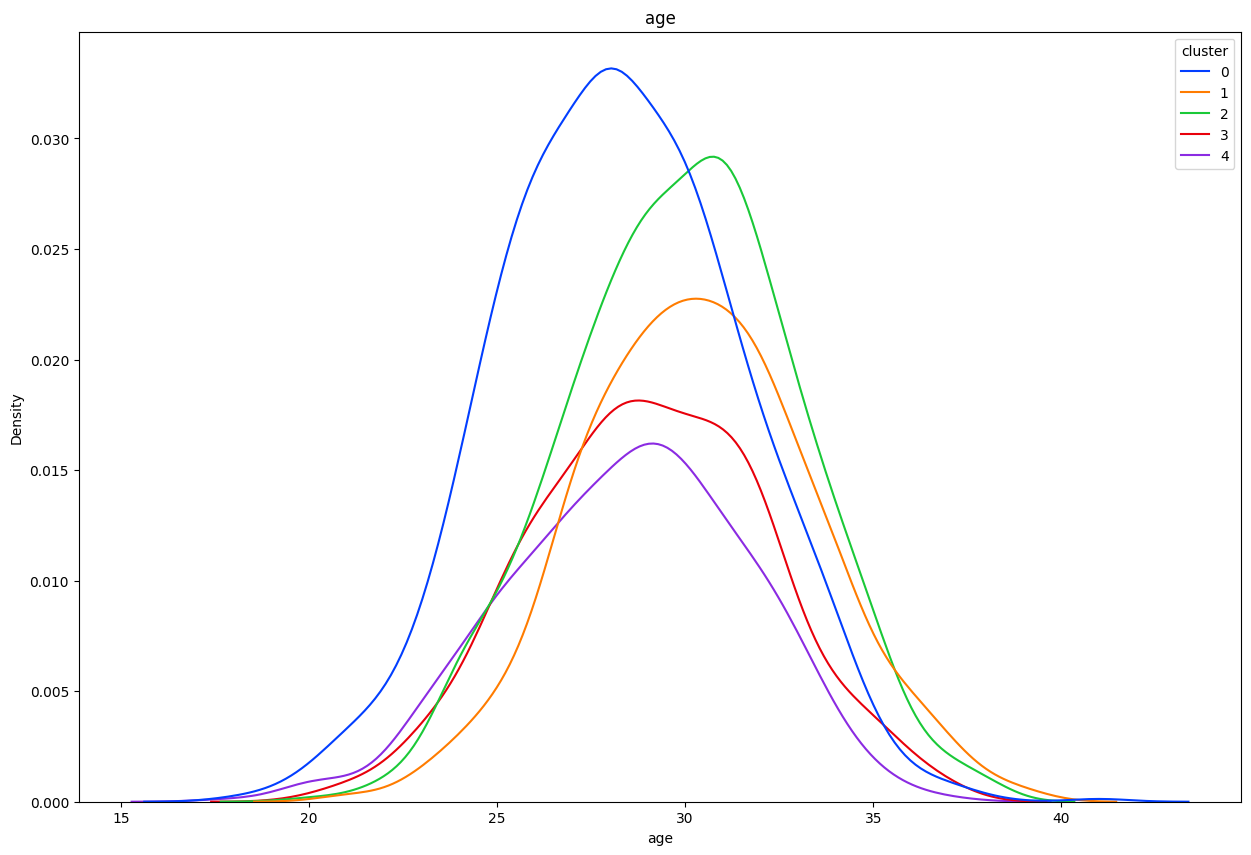

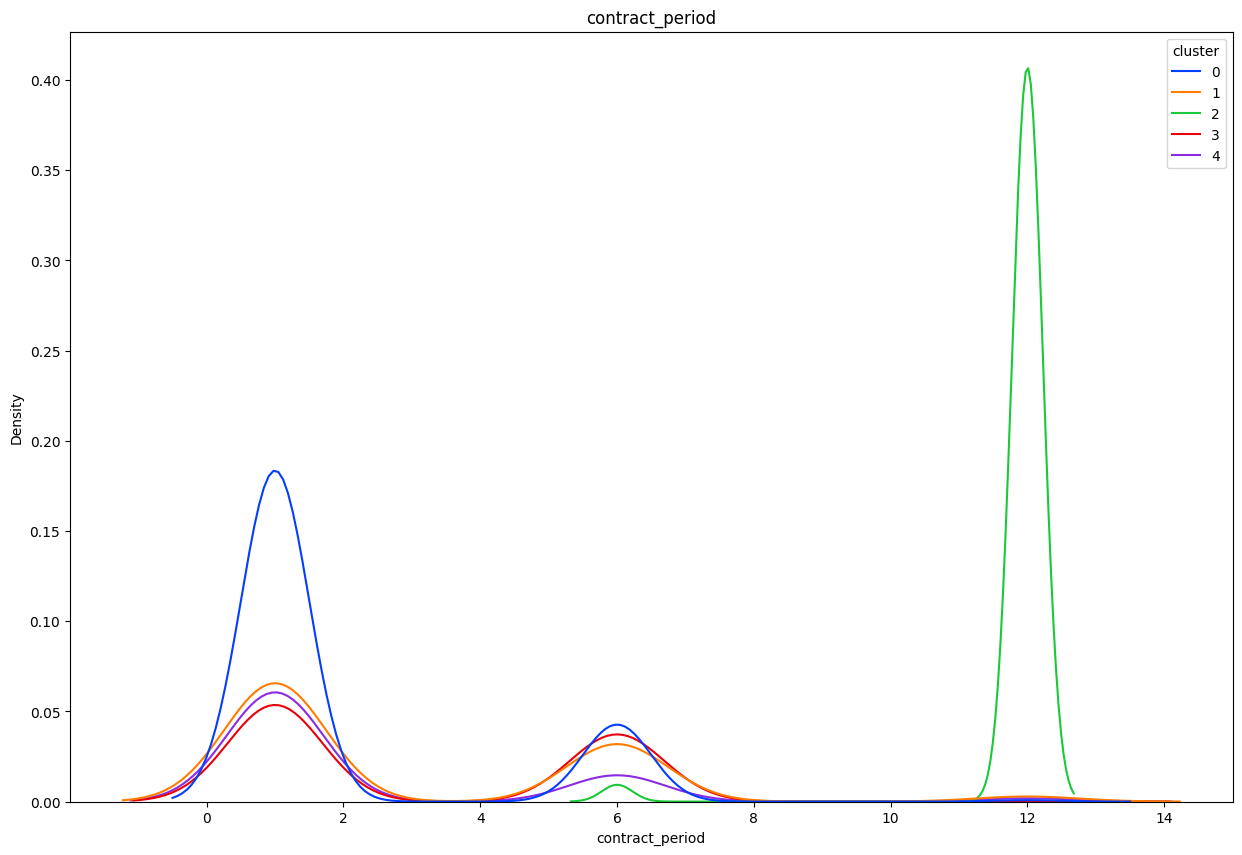

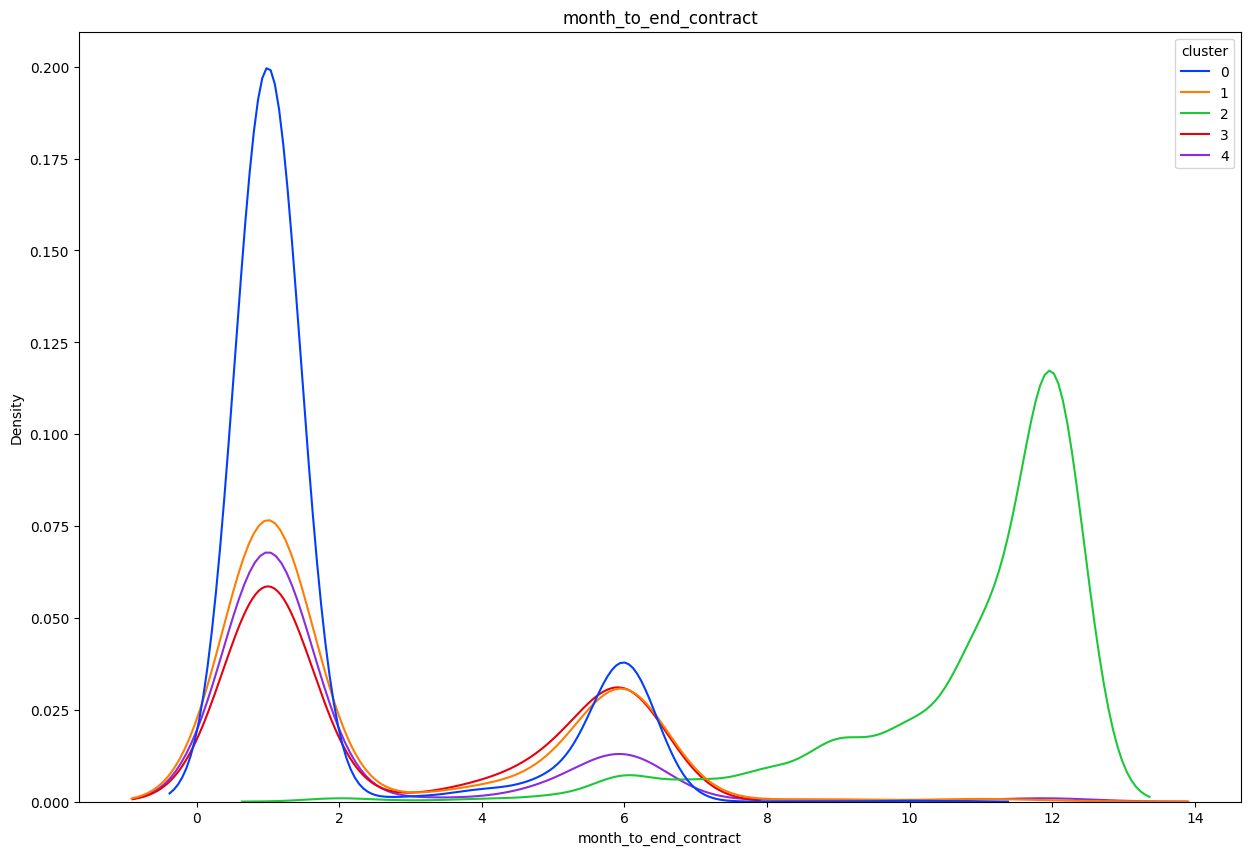

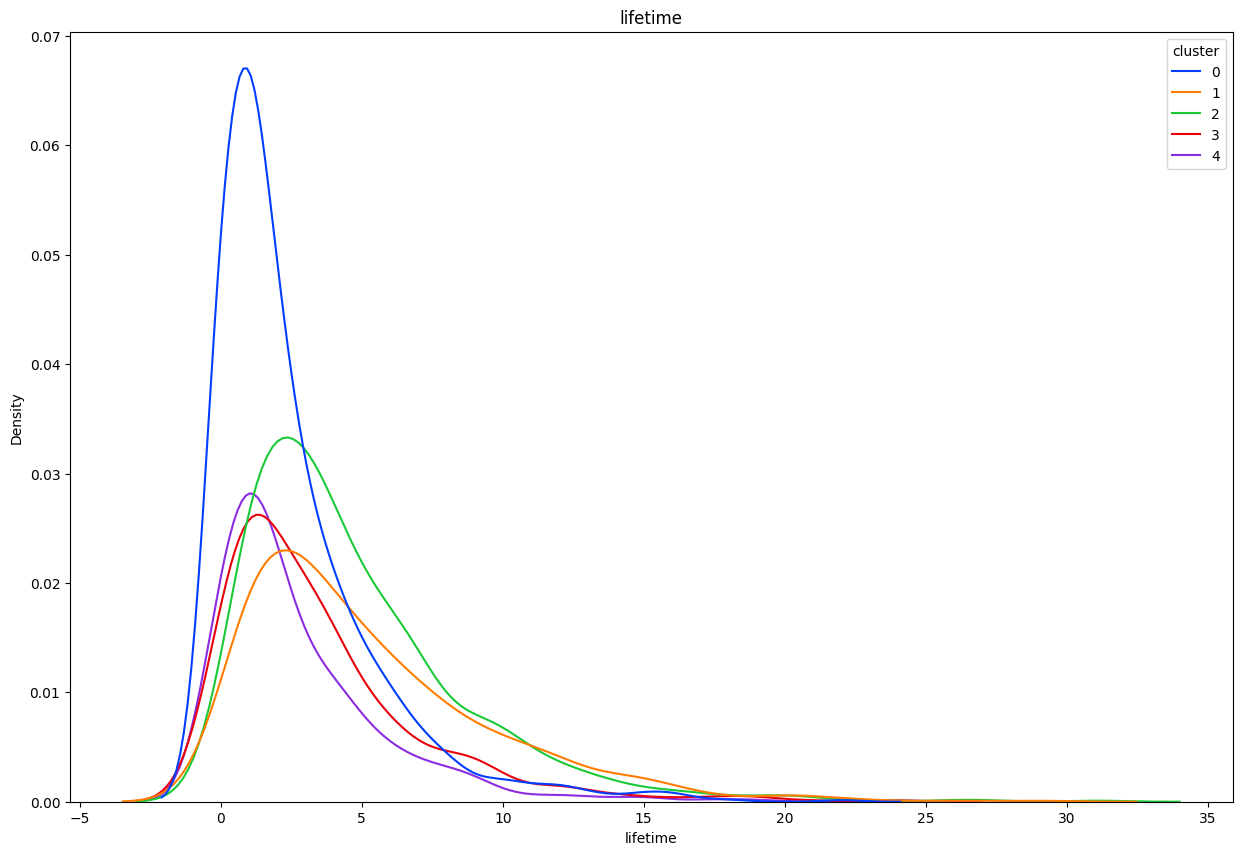

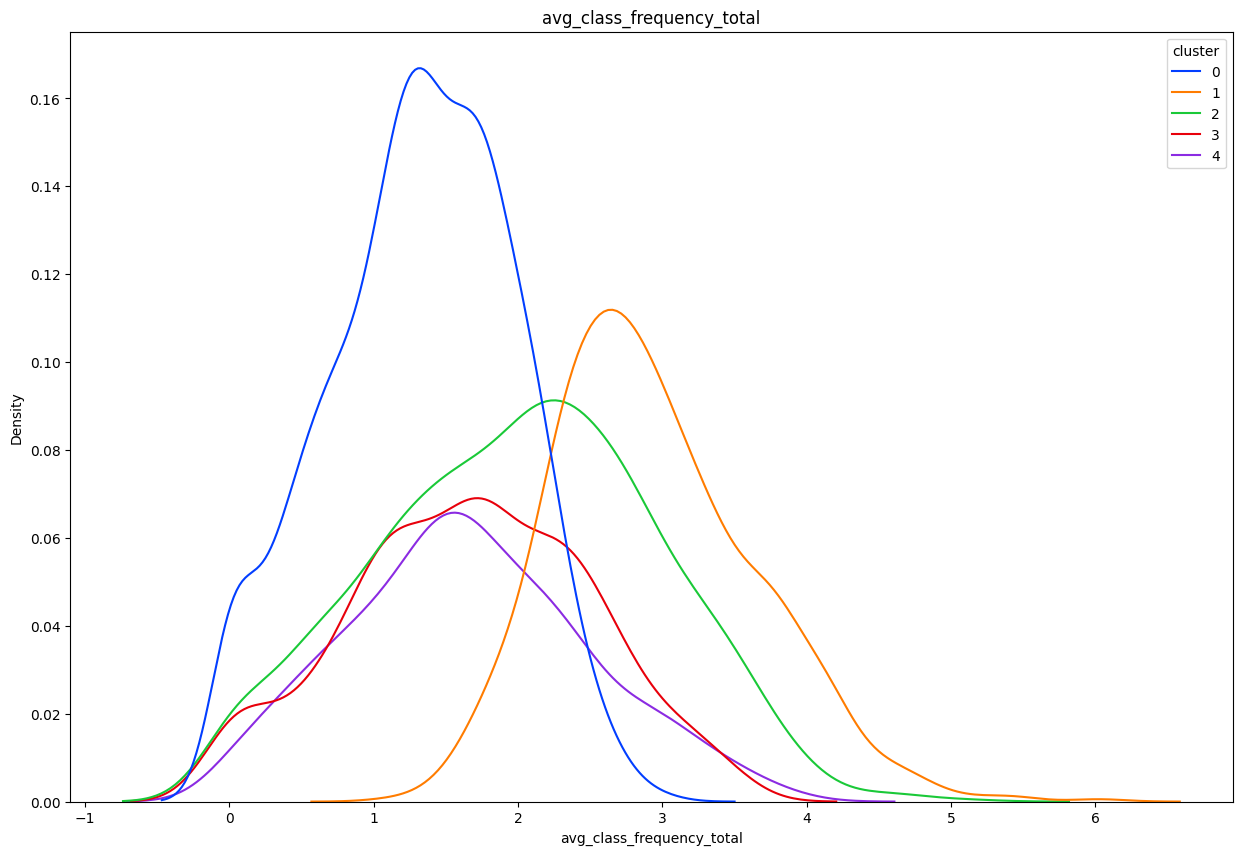

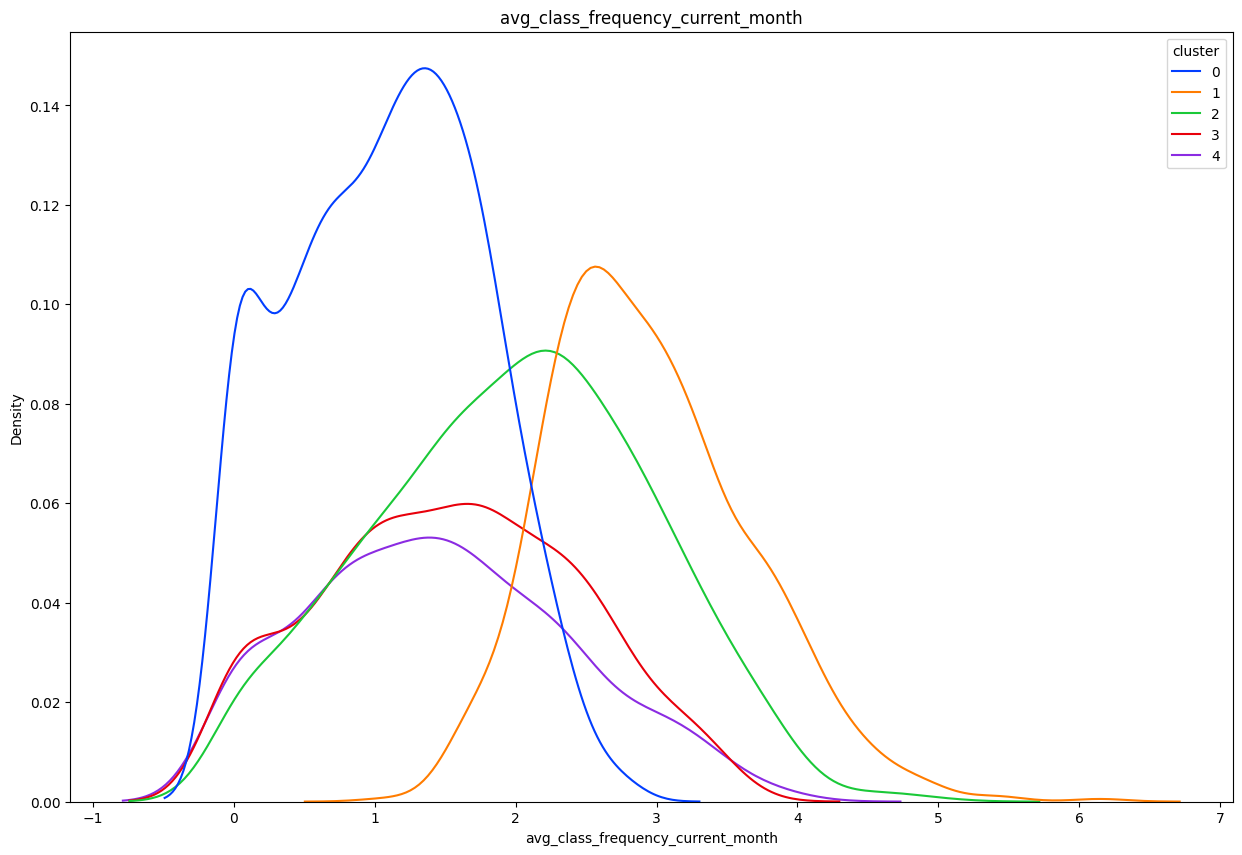

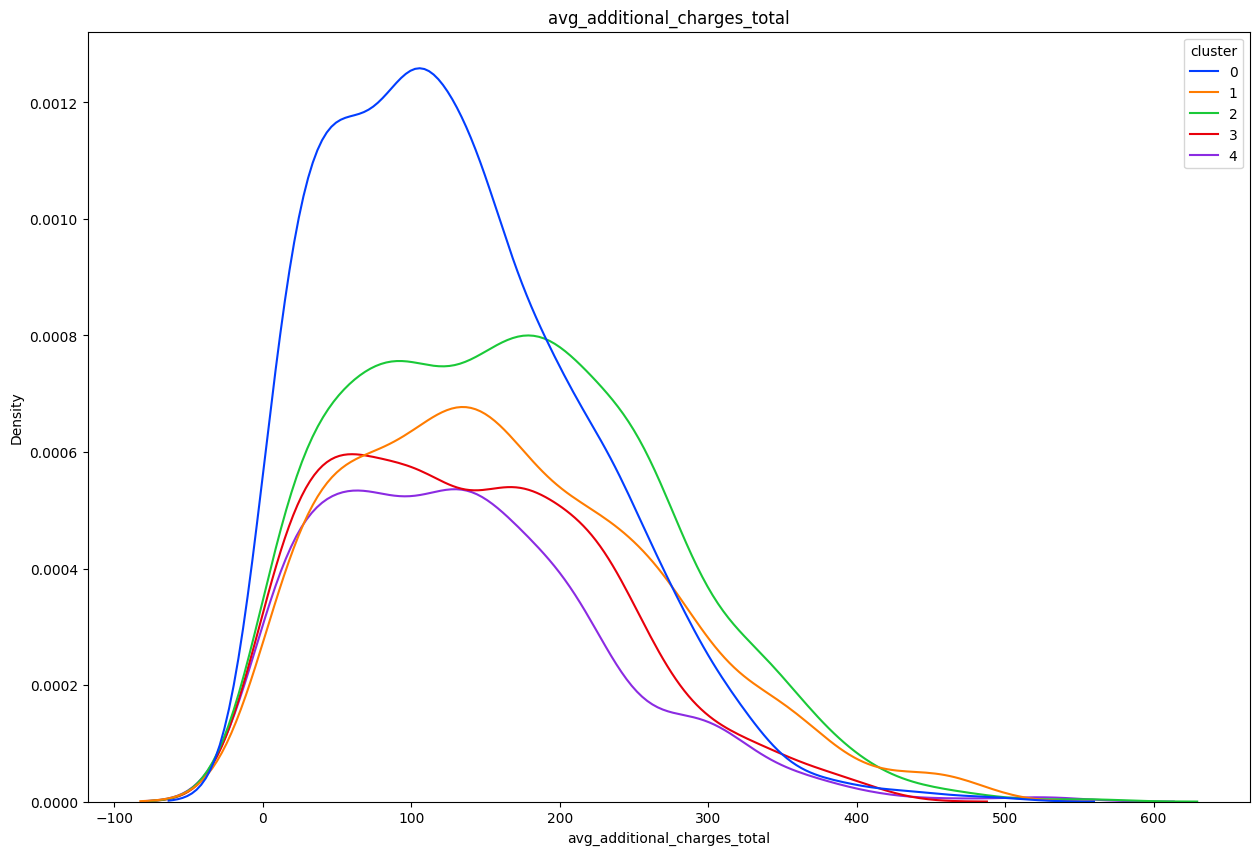

In [ ]:
# Графики распределения числовых признаков по кластерам
for col in num_features:
    plt.figure(figsize=(15, 10))
    sns.kdeplot(data=df, x=col, hue='cluster', palette='bright')
    plt.title(col)
    plt.show()

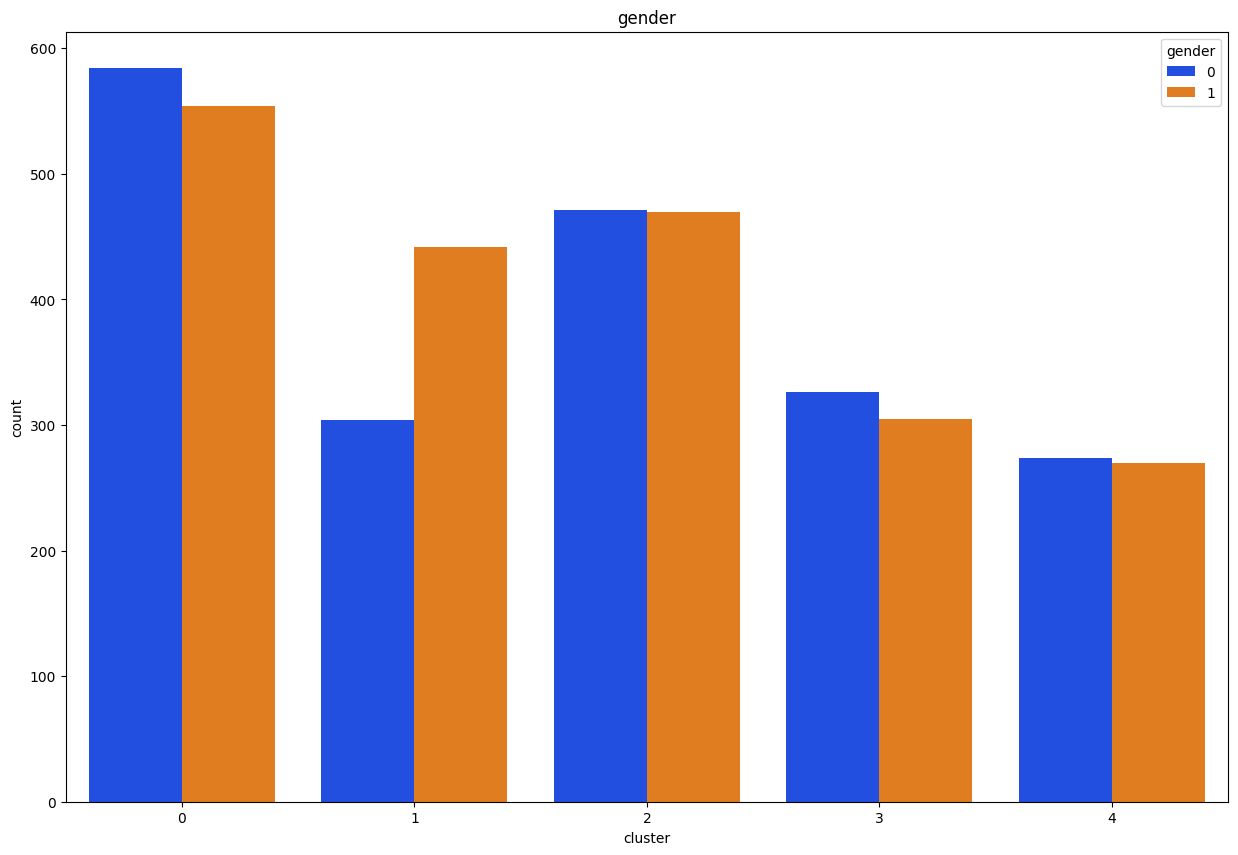

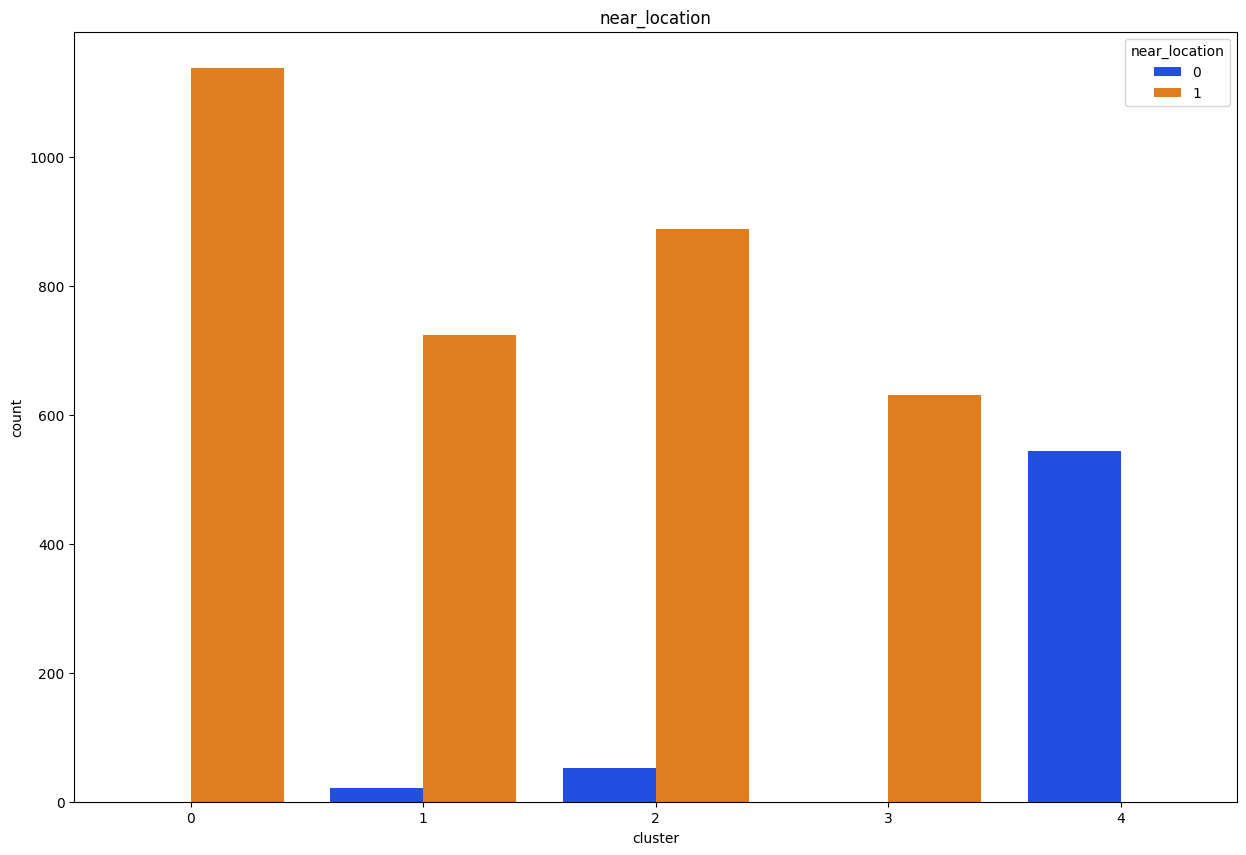

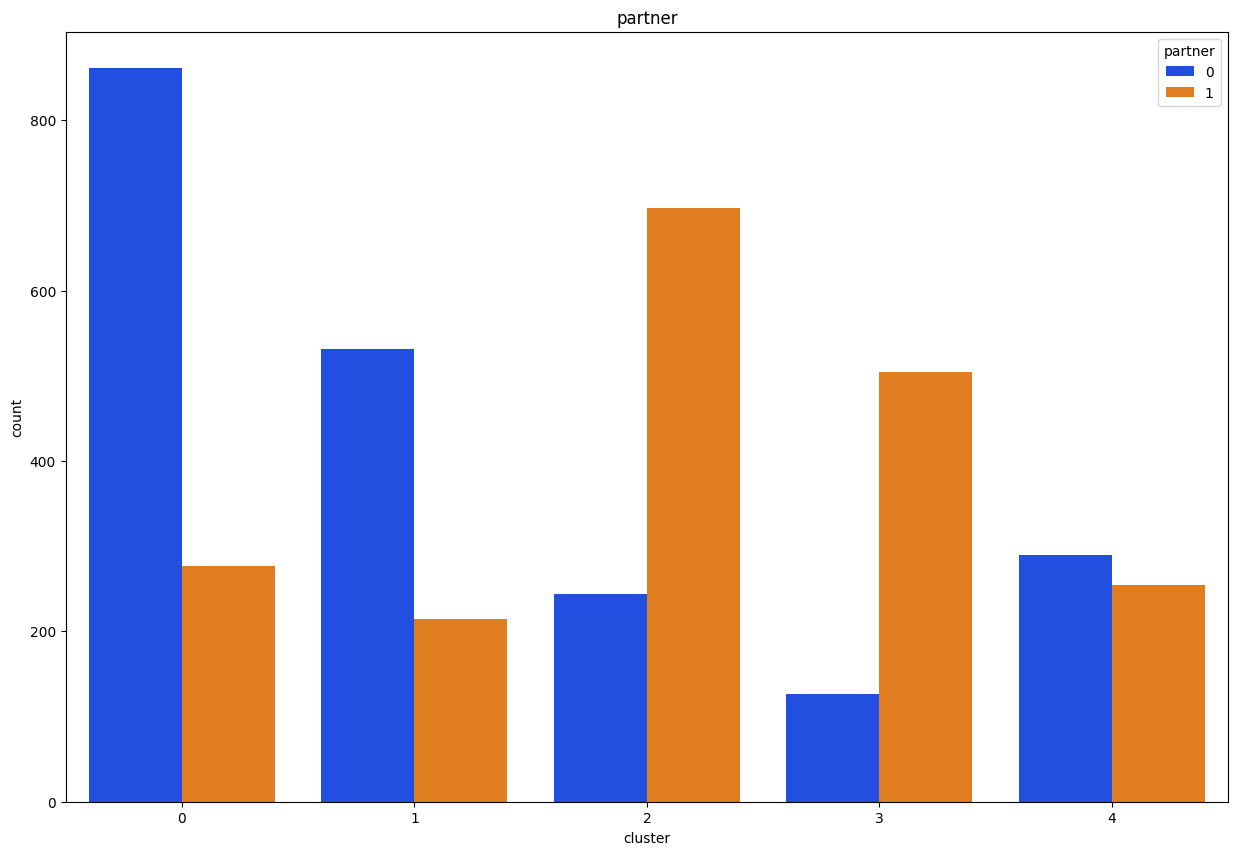

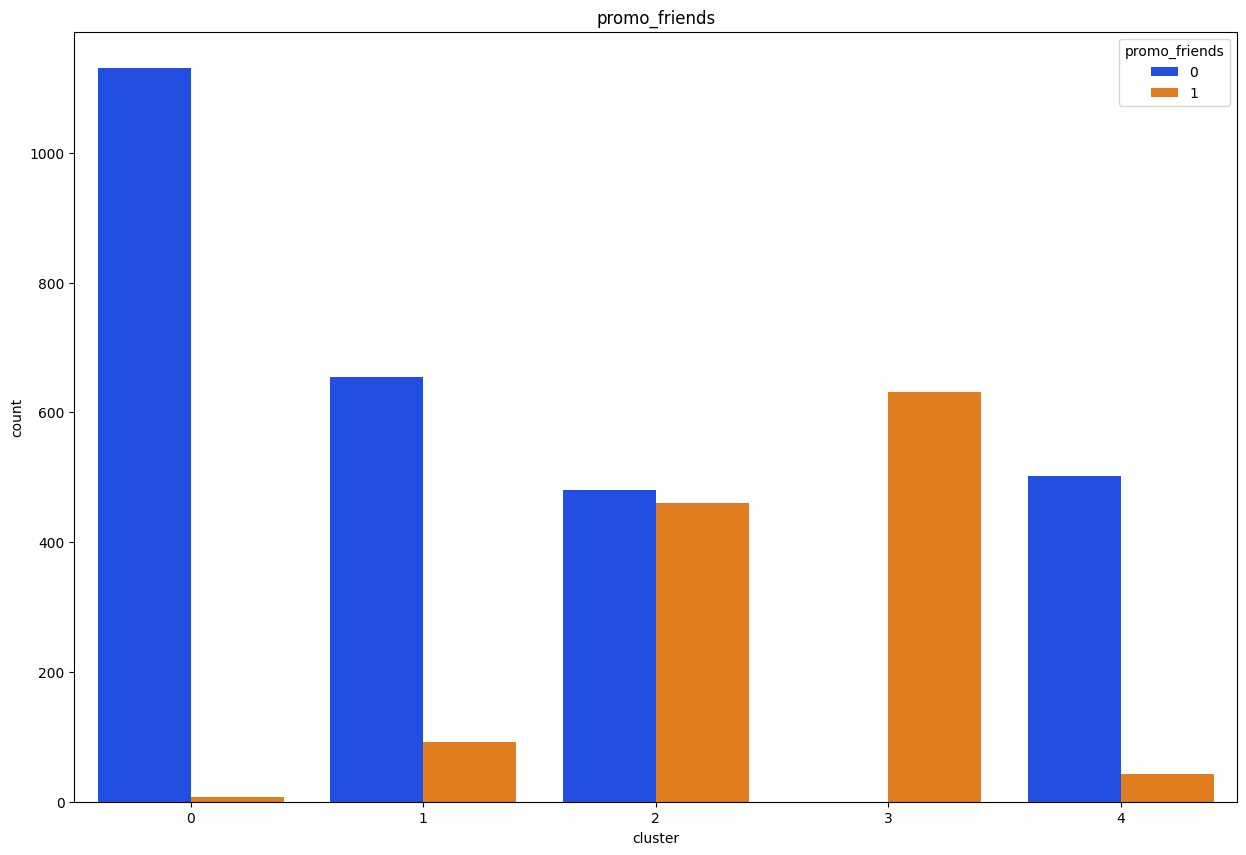

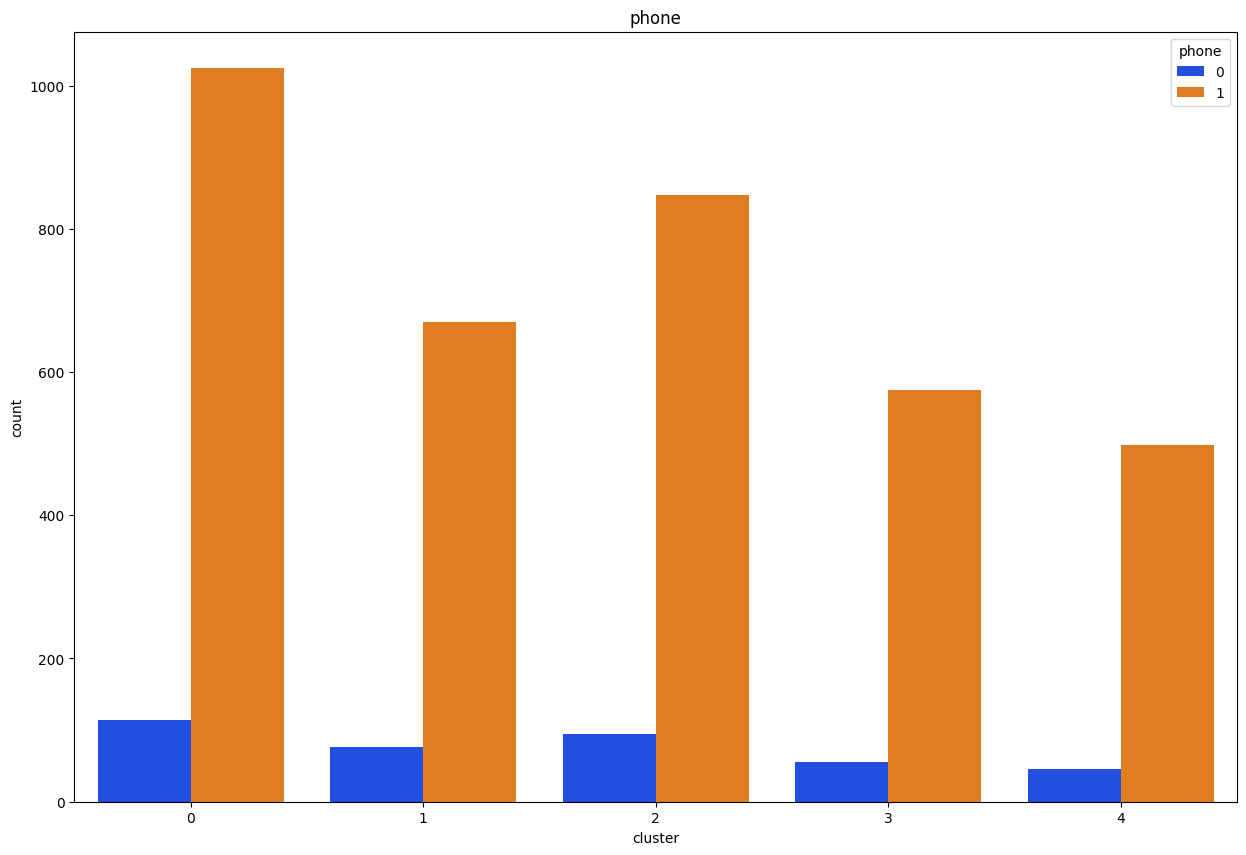

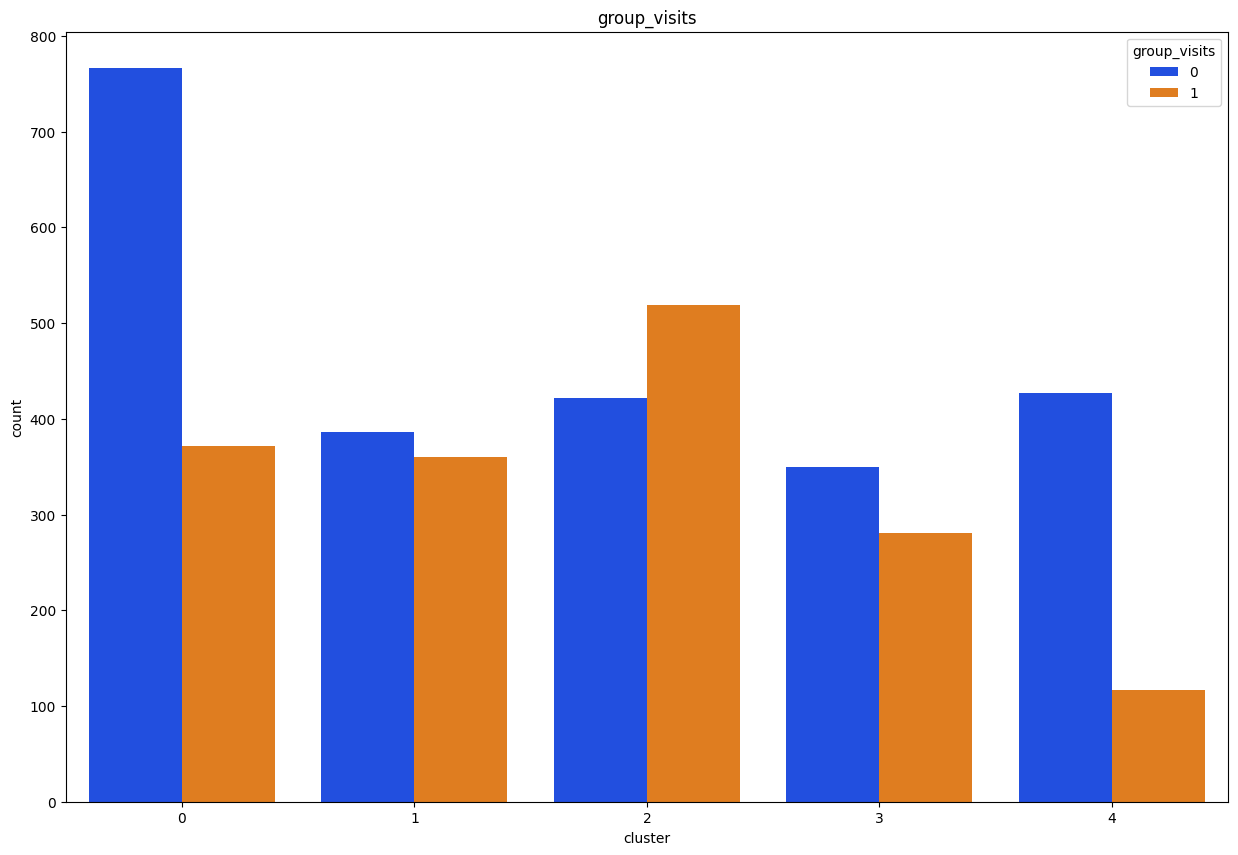

In [ ]:
# Диаграммы распределения бинарных признаков по кластерам
for col in bin_features:
    plt.figure(figsize=(15, 10))
    sns.countplot(data=df, x='cluster', hue=col, palette='bright')
    plt.title(col)
    plt.show()

**Вывод:**
В результате кластеризации было выделено 5 групп. 
Самые нестабильные к оттоку кластеры - 0 (51%) и 4 (45%). К ним относятся 1138 и 544 участников, соответственно. 

Для клиентов кластера 0 характерны короткие абонементы, небольшой lifetime и невысокая частота посещений фитнес-центра — в среднем около 1–2 раз в неделю. Они меньше тратят на дополнительные услуги, редко участвуют в партнёрских программах и практически не приходят по акции «Приведи друга». Около трети клиентов посещают групповые занятия.

Кластер 4 также характеризуется высокой долей оттока. Главная особенность этой группы — отсутствие близкого расположения фитнес-центра к месту проживания или работы клиентов. У них короткие абонементы, небольшой lifetime и относительно низкая частота посещений. Клиенты этого кластера также немного тратят на дополнительные услуги, редко участвуют в акции «Приведи друга» и реже посещают групповые занятия.

Наименее склонными к оттоку оказались кластер 1 (5,5%) и кластер 2 (2,2%). В них находится 746 и 941 клиент соответственно.

Клиенты кластера 1 чаще имеют более длительные абонементы, дольше взаимодействуют с фитнес-центром и посещают его чаще — около 2–4 раз в неделю. Они также больше тратят на дополнительные услуги. Почти все клиенты живут или работают рядом с фитнес-центром, а значительная часть является клиентами-партнёрами.

Кластер 2 отличается наиболее длительными абонементами — в среднем около 12 месяцев. Клиенты достаточно долго взаимодействуют с фитнес-центром, регулярно посещают его и имеют относительно высокие дополнительные расходы. Почти все находятся рядом с фитнес-центром. Около половины клиентов были привлечены по акции «Приведи друга», более половины посещают групповые занятия.

Кластер 3 является промежуточным: отток составляет 26,9%, в кластере находится 631 клиент. Для этой группы характерны относительно короткие абонементы, небольшой lifetime и умеренная частота посещений. Все клиенты живут или работают рядом с фитнес-центром, большинство являются клиентами-партнёрами, и все были привлечены по акции «Приведи друга».

Таким образом, кластеризация позволила разделить клиентов на группы в зависимости от длительности абонемента, частоты посещения и lifetime. Наиболее проблемными являются клиенты с короткими абонементами, небольшим lifetime и низкой частотой посещений. Более стабильными являются клиенты с длительными абонементами, регулярными посещениями и более высокой вовлечённостью в дополнительные услуги и активности фитнес-центра.

## 5. Общий вывод.

В ходе проекта был проведён анализ данных о клиентах фитнес-центра с целью спрогнозировать вероятность оттока клиентов и понять факторы, связанные с уходом. 

**Исследовательский анализ** показал, что клиенты, которые уходят, в среднем имеют *меньшую длительность* взаимодействия с фитнес-центром, более *короткие абонементы* и посещают фитнес-центр *реже*. Для них также характерны *меньшие расходы* на дополнительные услуги и *меньшая вовлечённость* в групповые занятия. Среди ушедших клиентов *ниже* доля участников партнёрских программ и клиентов, пришедших по акции «Приведи друга». При этом *пол* клиента практически *не различается* между группами и не является значимым признаком с точки зрения анализа оттока.

Для прогнозирования оттока были построены две **модели**: *логистическая регрессия* и *случайный лес*. *Логистическая регрессия* показала следующие результаты: Accuracy — 0,899, Precision — 0,788, Recall — 0,808, F1-score — 0,798. Для *случайного леса* значения составили соответственно 0,890, 0,786, 0,763 и 0,774. На данной тестовой выборке *логистическая регрессия* показала более высокие значения всех рассмотренных метрик, поэтому именно её можно использовать как *основную* модель для прогнозирования оттока в рамках данного проекта.

Дополнительно была проведена **кластеризация** клиентов. После стандартизации признаков с помощью метода K-Means были выделены *5 кластеров*. Кластеры заметно различаются по длительности абонементов, lifetime, частоте посещений, дополнительным расходам, участию в партнёрских программах и групповых занятиях, а также по уровню оттока.

Наиболее *высокая доля* оттока наблюдается в кластере 0 — 51,3% и кластере 4 — 45,0%. Для этих групп характерны короткие абонементы, небольшой lifetime и сравнительно низкая частота посещений. При этом клиенты кластера 4 дополнительно отличаются тем, что не живут и не работают рядом с фитнес-центром. Промежуточный уровень оттока наблюдается в кластере 3 — 26,9%.

Наиболее *низкая доля* оттока наблюдается в кластере 1 — 5,5% и кластере 2 — 2,2%. Для этих клиентов характерны более длительные абонементы, более высокая частота посещений, больший lifetime и более высокая вовлечённость в дополнительные услуги и активности фитнес-центра.

Таким образом, проведённый анализ показывает, что с оттоком связаны прежде всего *длительность* абонемента, *регулярность* посещений и уровень вовлечённости в *дополнительные* услуги и групповые занятия. Для снижения оттока целесообразно уделять особое внимание клиентам с короткими абонементами, небольшим lifetime и низкой частотой посещений. Чтобы удержать таких клиентов, можно использовать персональные предложения по продлению абонемента, стимулирование регулярных посещений и вовлечение в групповые занятия и дополнительные услуги.
